# Inter-case perspective — inter-case drifts

Drifts in the case population and timing: **arrival_rate** (how often cases start), **amount** (case value), **waiting_time** (gaps between events / throughput), **region** (case origin mix). Crimson lines come from `rheon:metadata`.

In [1]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})

ROOT = Path.cwd()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
LOG = ROOT / "data" / "inter.xes"
PERSPECTIVE = "inter-case"
WINDOW_DAYS = 45
NS = "{http://www.xes-standard.org/}"


def read_metadata(path):
    """Pull the rheon:metadata JSON from the log header without parsing every trace."""
    for event, elem in ET.iterparse(str(path), events=("start", "end")):
        if event == "end" and elem.tag == f"{NS}string" and elem.attrib.get("key") == "rheon:metadata":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{NS}trace":
            break
    return {}


meta = read_metadata(LOG)
drifts = [d for d in meta.get("drifts", []) if d["perspective"] == PERSPECTIVE]
for d in drifts:
    d["date"] = pd.Timestamp(d.get("drift_point_date") or d["drift_start_date"])

pd.DataFrame([{"id": d["id"], "type": d["type"], "mode": d["mode"], "date": d["date"]}
             for d in drifts])

,id,type,mode,date
0,d01,arrival_rate,sudden,2020-03-14 00:00:00+00:00
1,d02,amount,sudden,2020-06-13 06:00:00+00:00
2,d03,waiting_time,sudden,2020-08-25 06:00:00+00:00
3,d04,region,sudden,2020-11-06 06:00:00+00:00


In [2]:
df = pm4py.read_xes(str(LOG)).rename(columns={
    "case:concept:name": "case", "concept:name": "activity",
    "start_timestamp": "start", "time:timestamp": "end",
    "org:resource": "resource", "event:duration_min": "duration",
    "case:amount": "amount", "case:region": "region",
})
df["start"] = pd.to_datetime(df["start"], utc=True)
df["end"] = pd.to_datetime(df["end"], utc=True)
df = df.sort_values(["case", "start"]).reset_index(drop=True)
df["week"] = df["end"].dt.to_period("W").dt.start_time
df["wait_min"] = ((df["start"] - df.groupby("case")["end"].shift()).dt.total_seconds() / 60).clip(lower=0)

cases = (df.groupby("case")
         .agg(start=("start", "min"), end=("end", "max"), length=("activity", "size"),
              variant=("activity", " ".join), amount=("amount", "first"), region=("region", "first"))
         .reset_index().sort_values("start").reset_index(drop=True))
cases["week"] = cases["start"].dt.to_period("W").dt.start_time
cases["gap_min"] = cases["start"].diff().dt.total_seconds() / 60

acts = sorted(df["activity"].unique())
ress = sorted(df["resource"].dropna().unique())
ACT = dict(zip(acts, map(to_hex, sns.color_palette("Set2", max(len(acts), 1)))))
RES = dict(zip(ress, map(to_hex, sns.color_palette("tab20", max(len(ress), 1)))))


def drift_lines(ax, subset=None):
    """Mark drift change points on a time axis."""
    for d in (drifts if subset is None else subset):
        ax.axvline(d["date"], color="crimson", ls="--", lw=1, alpha=0.8)
        ax.annotate(d["id"], (d["date"], 1), xycoords=("data", "axes fraction"),
                    ha="center", va="bottom", fontsize=8, color="crimson")


def window(d, by="event", days=WINDOW_DAYS):
    """Events (by='event') or cases (by='case') just before vs after a drift, clipped to neighbours."""
    t = d["date"]
    near = [x["date"] for x in drifts if x["date"] != t]
    lo = max([t - pd.Timedelta(days=days)] + [o for o in near if o < t])
    hi = min([t + pd.Timedelta(days=days)] + [o for o in near if o > t])
    if by == "case":
        return (cases[(cases["start"] >= lo) & (cases["start"] < t)],
                cases[(cases["start"] >= t) & (cases["start"] < hi)])
    return df[(df["end"] >= lo) & (df["end"] < t)], df[(df["end"] >= t) & (df["end"] < hi)]

/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/bd/Projects/thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████| 7304/7304 [00:00<00:00, 17529.51it/s]
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_65152/1234163824.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["end"].dt.to_period("W").dt.start_time
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_65152/1234163824.py:17: UserWarning: Converting to P

In [3]:
regions = sorted(cases["region"].unique())
REG = dict(zip(regions, map(to_hex, sns.color_palette("Set3", max(len(regions), 1)))))

## Overview

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_65152/1836294974.py:16: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  wr = wr.div(wr.sum(1), axis=0)


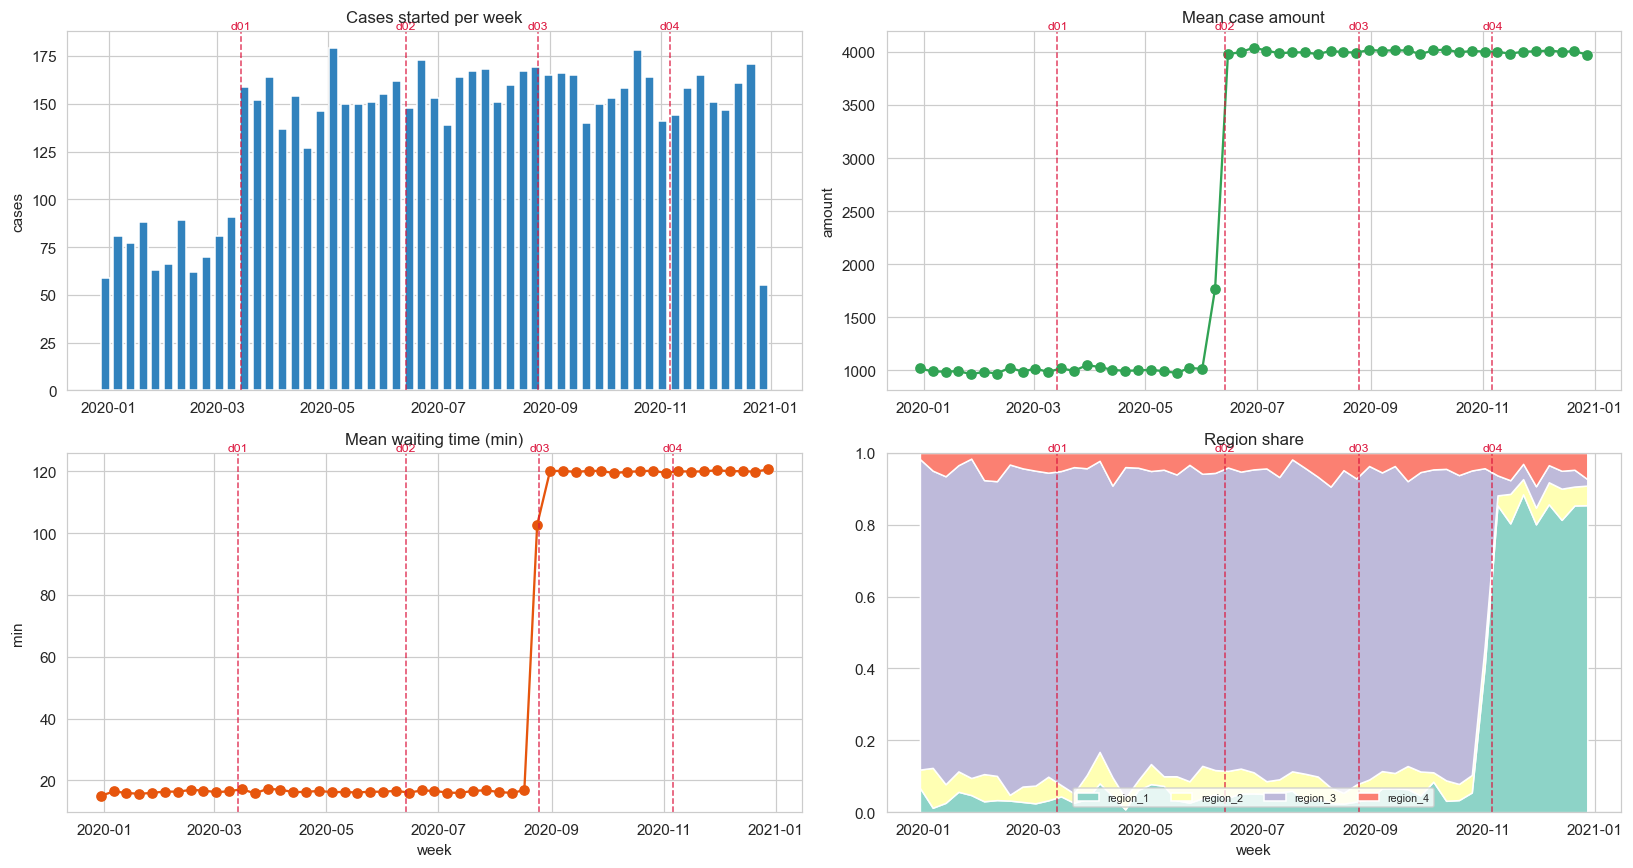

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

cs = cases.groupby("week").size()
ax[0, 0].bar(cs.index, cs.values, width=5, color="#3182bd")
ax[0, 0].set(title="Cases started per week", ylabel="cases"); drift_lines(ax[0, 0])

am = cases.groupby("week")["amount"].mean()
ax[0, 1].plot(am.index, am.values, marker="o", color="#31a354")
ax[0, 1].set(title="Mean case amount", ylabel="amount"); drift_lines(ax[0, 1])

ww = df.groupby("week")["wait_min"].mean()
ax[1, 0].plot(ww.index, ww.values, marker="o", color="#e6550d")
ax[1, 0].set(title="Mean waiting time (min)", xlabel="week", ylabel="min"); drift_lines(ax[1, 0])

wr = cases.groupby(["week", "region"]).size().unstack(fill_value=0).reindex(columns=regions, fill_value=0)
wr = wr.div(wr.sum(1), axis=0)
ax[1, 1].stackplot(wr.index, wr.T.values, labels=regions, colors=[REG[r] for r in regions])
ax[1, 1].set(title="Region share", xlabel="week", ylim=(0, 1))
ax[1, 1].legend(ncol=len(regions), fontsize=7, loc="lower center"); drift_lines(ax[1, 1])
plt.tight_layout(); plt.show()

## Before vs after each drift

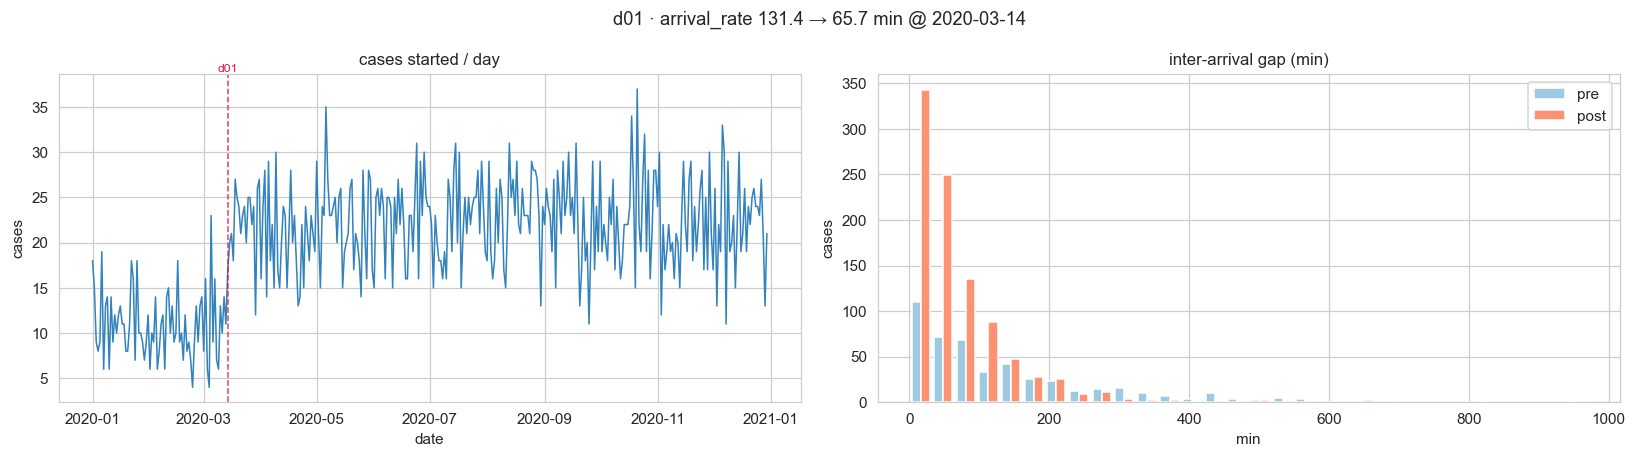

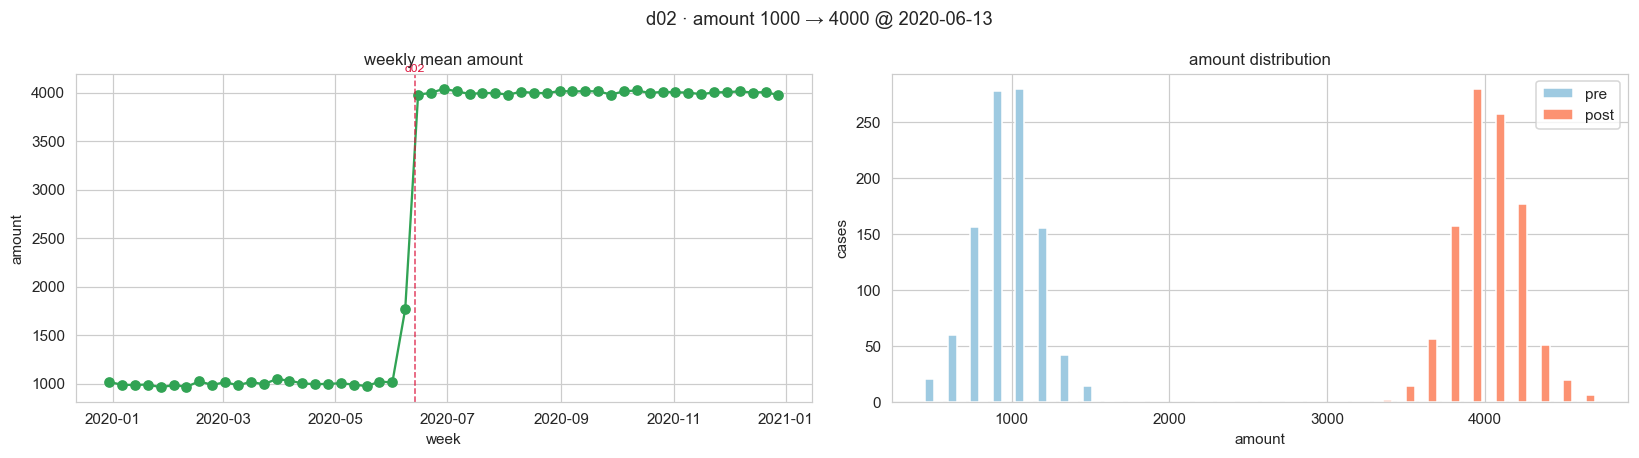

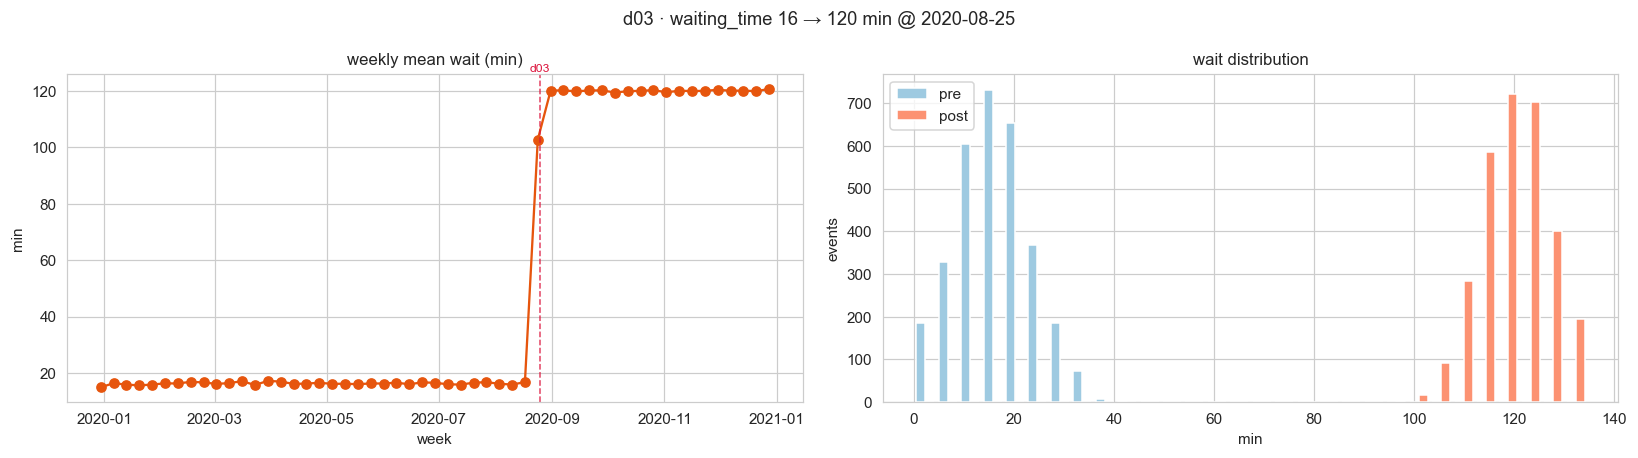

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_65152/1751273510.py:37: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  wr = wr.div(wr.sum(1), axis=0)


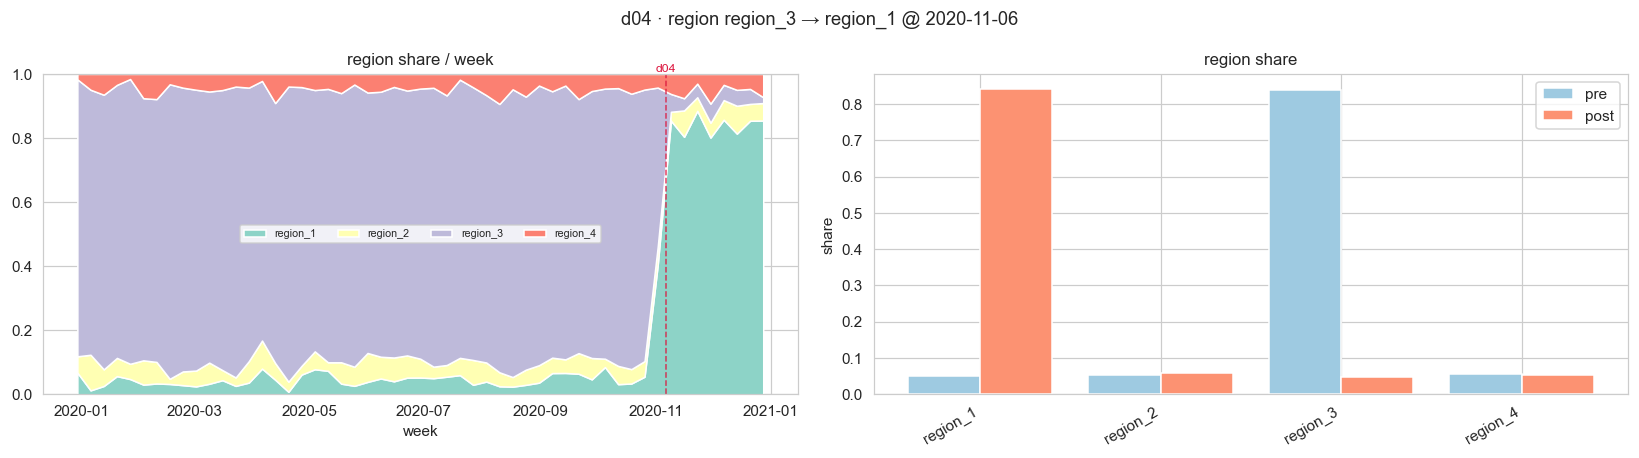

In [5]:
for d in drifts:
    c, t = d["changes"], d["type"]
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))

    if t == "arrival_rate":
        cpre, cpost = window(d, by="case")
        fig.suptitle(f"{d['id']} \u00b7 arrival_rate {c['inter_arrival_before']} \u2192 {c['inter_arrival_after']} min @ {d['date']:%Y-%m-%d}")
        daily = cases.set_index("start").resample("D").size()
        ax[0].plot(daily.index, daily.values, color="#3182bd", lw=1)
        ax[0].set(title="cases started / day", xlabel="date", ylabel="cases"); drift_lines(ax[0], [d])
        ax[1].hist([cpre["gap_min"].dropna(), cpost["gap_min"].dropna()], bins=30, label=["pre", "post"], color=["#9ecae1", "#fc9272"])
        ax[1].set(title="inter-arrival gap (min)", xlabel="min", ylabel="cases"); ax[1].legend()

    elif t == "amount":
        cpre, cpost = window(d, by="case")
        fig.suptitle(f"{d['id']} \u00b7 amount {c['amount_mean_before']:.0f} \u2192 {c['amount_mean_after']:.0f} @ {d['date']:%Y-%m-%d}")
        am = cases.groupby("week")["amount"].mean()
        ax[0].plot(am.index, am.values, marker="o", color="#31a354")
        ax[0].set(title="weekly mean amount", xlabel="week", ylabel="amount"); drift_lines(ax[0], [d])
        ax[1].hist([cpre["amount"], cpost["amount"]], bins=30, label=["pre", "post"], color=["#9ecae1", "#fc9272"])
        ax[1].set(title="amount distribution", xlabel="amount", ylabel="cases"); ax[1].legend()

    elif t == "waiting_time":
        pre, post = window(d, by="event")
        fig.suptitle(f"{d['id']} \u00b7 waiting_time {c['waiting_mean_before']:.0f} \u2192 {c['waiting_mean_after']:.0f} min @ {d['date']:%Y-%m-%d}")
        ww = df.groupby("week")["wait_min"].mean()
        ax[0].plot(ww.index, ww.values, marker="o", color="#e6550d")
        ax[0].set(title="weekly mean wait (min)", xlabel="week", ylabel="min"); drift_lines(ax[0], [d])
        cap = max(pd.concat([pre["wait_min"], post["wait_min"]]).quantile(.99), 1)
        ax[1].hist([pre["wait_min"].dropna(), post["wait_min"].dropna()], bins=30, range=(0, cap), label=["pre", "post"], color=["#9ecae1", "#fc9272"])
        ax[1].set(title="wait distribution", xlabel="min", ylabel="events"); ax[1].legend()

    else:  # region
        cpre, cpost = window(d, by="case")
        fig.suptitle(f"{d['id']} \u00b7 region {c['dominant_region_before']} \u2192 {c['dominant_region_after']} @ {d['date']:%Y-%m-%d}")
        wr = cases.groupby(["week", "region"]).size().unstack(fill_value=0).reindex(columns=regions, fill_value=0)
        wr = wr.div(wr.sum(1), axis=0)
        ax[0].stackplot(wr.index, wr.T.values, labels=regions, colors=[REG[r] for r in regions])
        ax[0].set(title="region share / week", xlabel="week", ylim=(0, 1)); ax[0].legend(ncol=len(regions), fontsize=7); drift_lines(ax[0], [d])
        x = np.arange(len(regions))
        ax[1].bar(x - 0.2, cpre["region"].value_counts(normalize=True).reindex(regions, fill_value=0).values, 0.4, label="pre", color="#9ecae1")
        ax[1].bar(x + 0.2, cpost["region"].value_counts(normalize=True).reindex(regions, fill_value=0).values, 0.4, label="post", color="#fc9272")
        ax[1].set_xticks(x); ax[1].set_xticklabels(regions, rotation=30, ha="right")
        ax[1].set(title="region share", ylabel="share"); ax[1].legend()

    plt.tight_layout(); plt.show()